# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama                      | NRP        |
|---------------------------|------------|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [14]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report as report,
    confusion_matrix as conf_matrix,
    accuracy_score as acc_score,
)

from collections import defaultdict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [15]:
# Additional step: mendownload dataset lewat API Kaggle
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv(dataset_file).drop(columns=["Id"])
data.head()
data.info()
data.describe()

Path to dataset files: /home/zico/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



Correlation Matrix with Pandas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


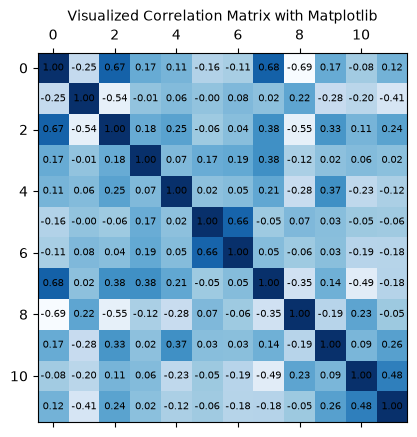

In [16]:
# Tampilkan Korelasi Matrix
corr_mat = data.corr()

fig, ax = plt.subplots()
columns = data.columns
min_val, max_val = 0, len(columns)

ax.set_title("Visualized Correlation Matrix with Matplotlib", fontsize=10)
ax.matshow(corr_mat, cmap=plt.cm.Blues  )

for i in range(len(columns)):
    for j in range(len(columns)):
        c = corr_mat[columns[j]][columns[i]]
        ax.text(i, j, f"{c:.2f}", va='center', ha='center', fontsize=7)
        
print("\nCorrelation Matrix with Pandas")
corr_mat

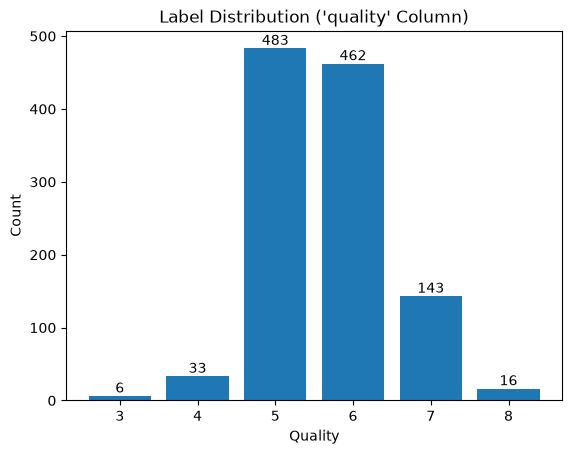

In [17]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
labels = data["quality"]
unique_labels = defaultdict(int)

for label in labels:
    unique_labels[label] += 1
    
label_count_pair   = [[key, val] for key, val in unique_labels.items()]
sort_label_by_name = sorted(label_count_pair, key=lambda x: x[0])

fig, ax = plt.subplots()
ax.bar(unique_labels.keys(), unique_labels.values())

ax.set_title("Label Distribution ('quality' Column)")
ax.set_xlabel("Quality")
ax.set_ylabel("Count")

num_label = len(unique_labels)
for i in range(num_label):
    label, count = sort_label_by_name[i]
    ax.text(label, count+5, count, ha="center")

plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [43]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
filter_nan_data = data.dropna()

duplicated_mask = filter_nan_data.duplicated(keep="first")
not_duplicate_data = filter_nan_data.loc[duplicated_mask == False]

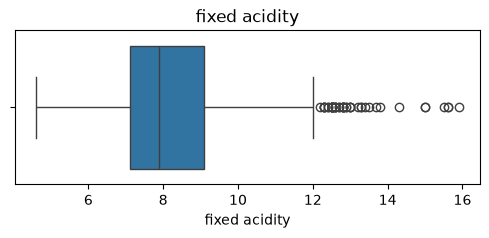

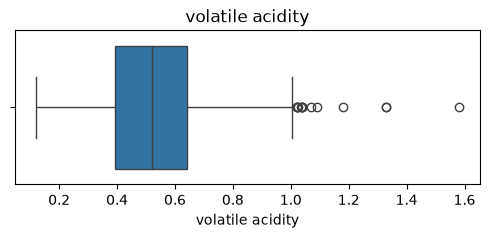

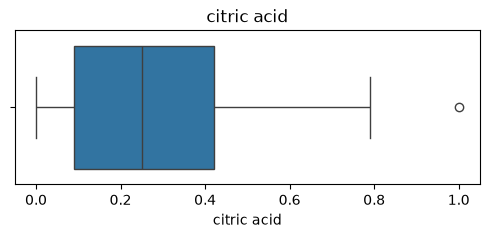

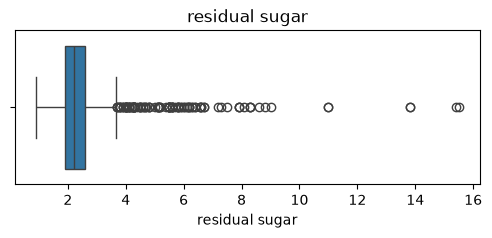

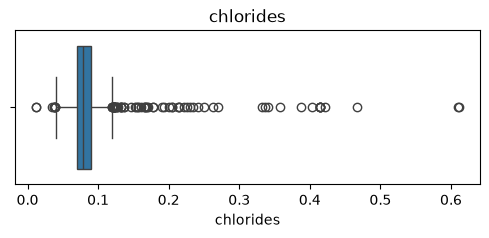

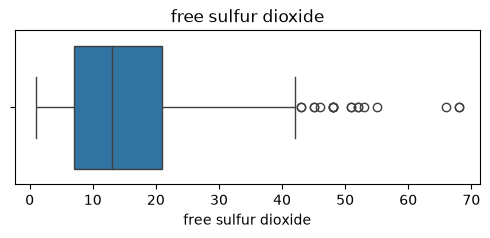

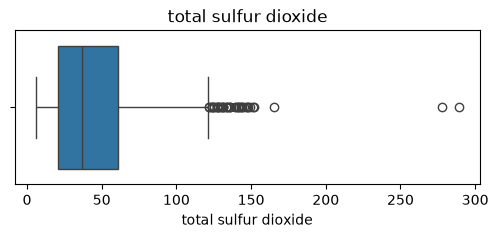

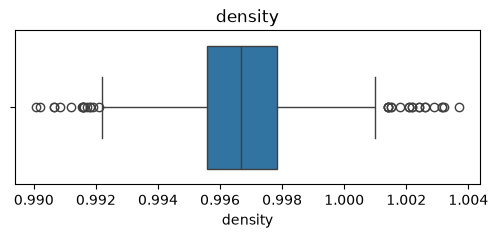

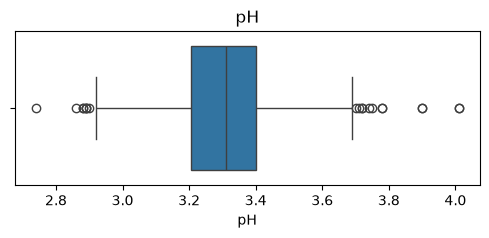

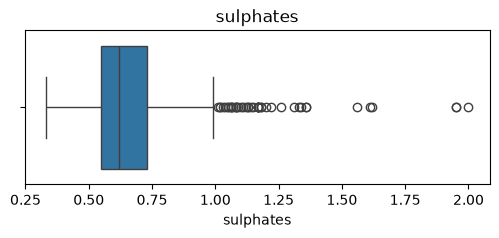

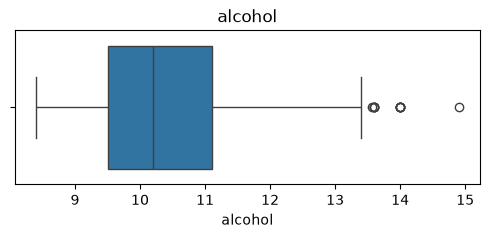

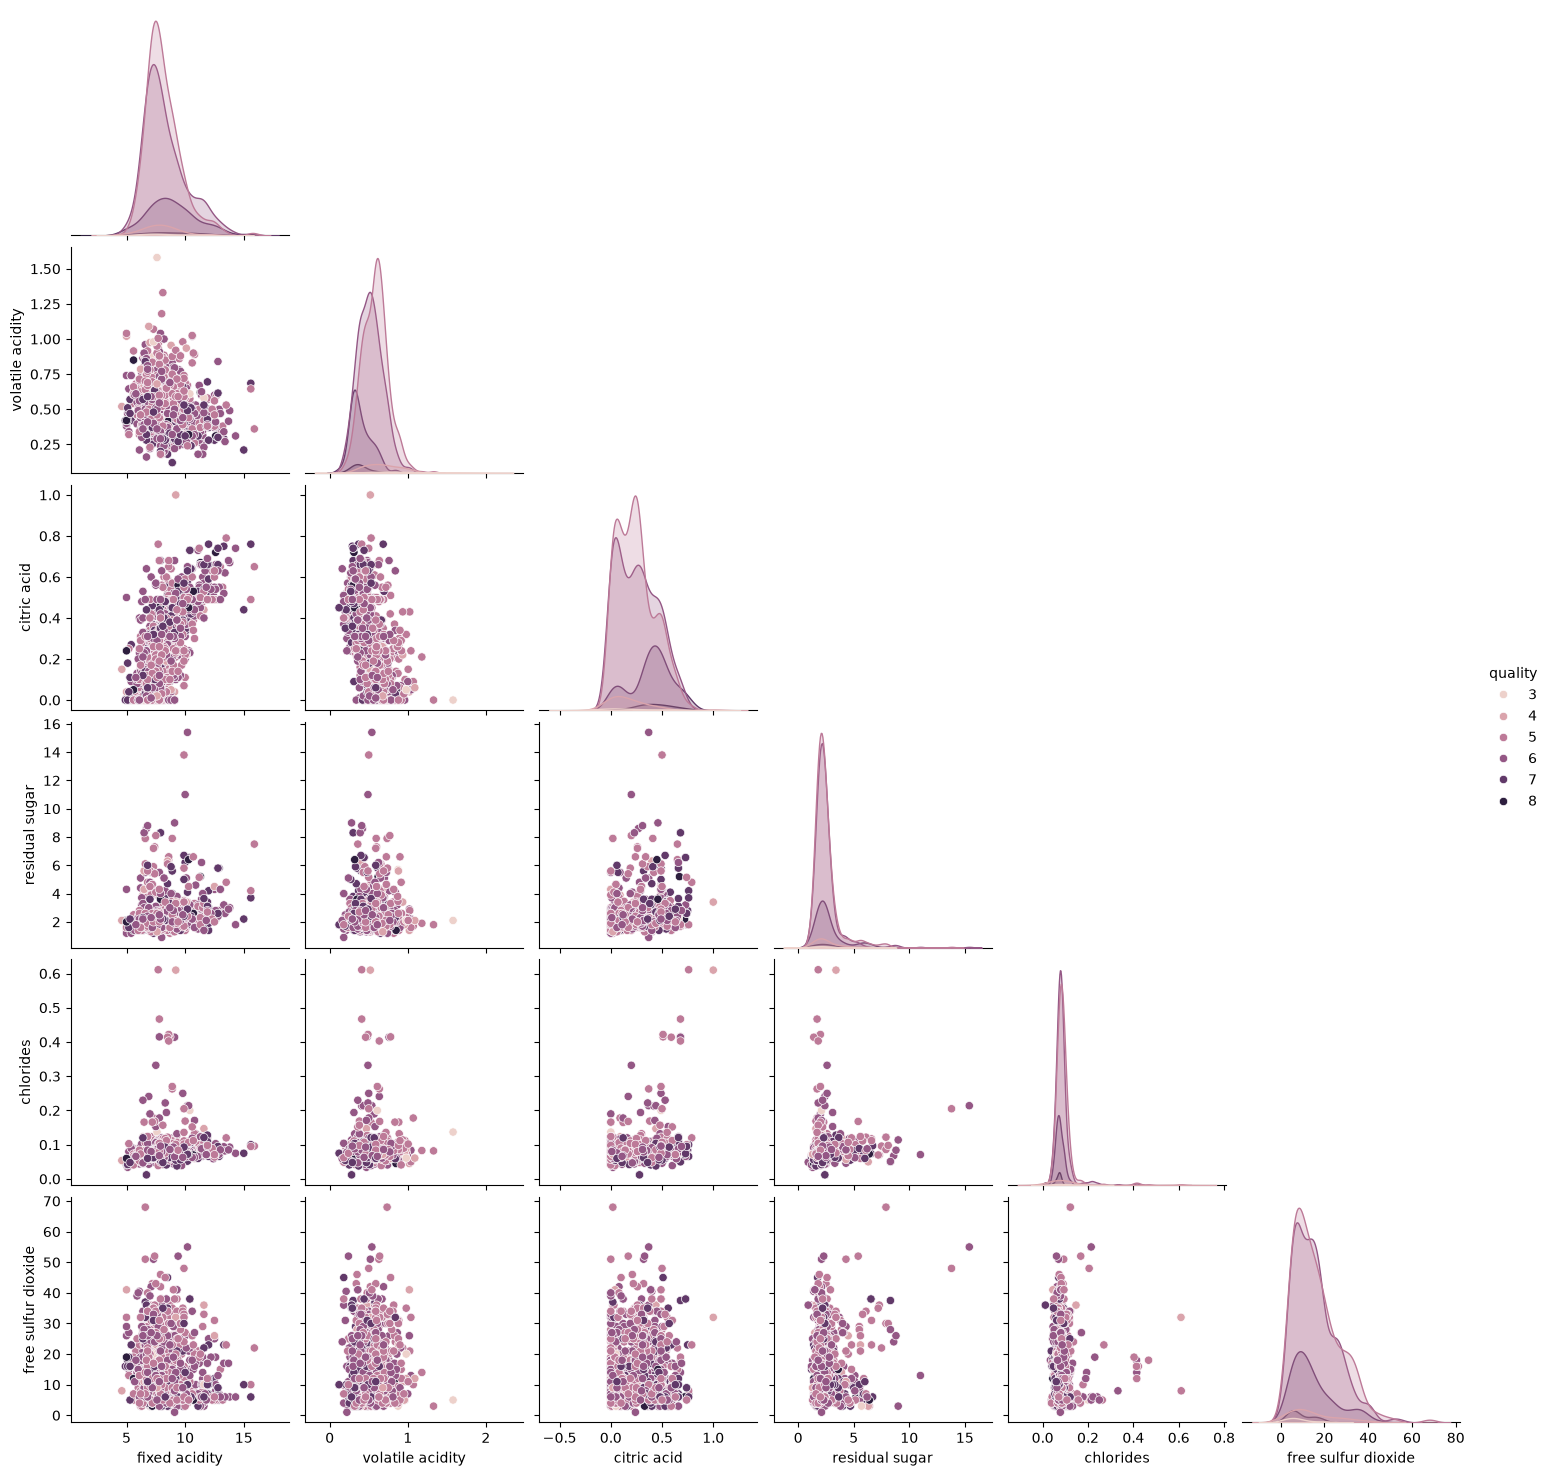

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,8.088624,0.531071,0.241455,2.200728,0.078343,14.855820,42.564815,0.996517,3.325331,0.630000,10.384061,5.637566
std,1.407022,0.170914,0.178808,0.451747,0.014446,8.690658,26.373020,0.001617,0.134261,0.112464,0.999874,0.776043
min,5.100000,0.120000,0.000000,1.200000,0.041000,1.000000,6.000000,0.992200,2.940000,0.330000,8.700000,3.000000
25%,7.100000,0.393750,0.080000,1.900000,0.069000,8.000000,22.000000,0.995500,3.230000,0.550000,9.500000,5.000000
50%,7.800000,0.530000,0.235000,2.100000,0.078000,13.000000,36.000000,0.996500,3.330000,0.610000,10.100000,6.000000
75%,8.900000,0.640000,0.382500,2.500000,0.087000,20.000000,58.000000,0.997525,3.410000,0.700000,11.000000,6.000000
max,12.000000,1.025000,0.730000,3.600000,0.119000,42.000000,122.000000,1.001000,3.680000,0.970000,13.600000,8.000000


In [44]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
feature_column = [c for c in not_duplicate_data.columns if c not in ["Id",'quality']]

for c in feature_column:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=data[c])
    plt.title(c)
    plt.show()

sns.pairplot(data.sample(1000, random_state=42), vars=feature_column[:6], hue='quality', corner=True)
plt.show()

filter_outlier = True
if filter_outlier:
    unfiltered_feature = not_duplicate_data[feature_column]
    q1 = unfiltered_feature.quantile(0.25)
    q3 = unfiltered_feature.quantile(0.75)
    iqr = q3 - q1
        
    lower = q1 - iqr*1.5
    upper = q3 + iqr*1.5
        
    inlier_mask = (unfiltered_feature >= lower) & (unfiltered_feature <= upper)
    reduced_inlier_mask = inlier_mask.all(axis=1)
    
    reduced_outlier_mask = ~reduced_inlier_mask
    
    inlier_data = not_duplicate_data[reduced_inlier_mask]
    
else:
    inlier_data = not_duplicate_data
    
inlier_data.describe()

In [45]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

scaler = StandardScaler()

# 3. Eksperimen Model KNN


In [46]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

TEST_SIZE = 0.2
SEED = 42
NEIGHBORS = range(1, 100)

feature_column = [c for c in not_duplicate_data.columns if c not in ["Id",'quality']]
X, y = inlier_data[feature_column], inlier_data['quality']

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.fit_transform(X_test_raw)
    
metric_collection = []
for n in NEIGHBORS:
    curr_n_info = {
        "n": n,
    }
    
    for info, train, test in zip(
        ["raw", "scaled"],
        [X_train_raw, X_train_scaled],
        [X_test_raw, X_test_scaled]
    ):
        model = KNeighborsClassifier(n_neighbors=n)
        model.fit(train, Y_train)

        y_pred = model.predict(test)
        metrics_score = {
            "report": report(Y_test, y_pred, output_dict=True),
            "accuracy": acc_score(Y_test, y_pred),
            "conf_matrix": conf_matrix(Y_test, y_pred)
        }
        
        curr_n_info[info] = metrics_score
        
    metric_collection.append(curr_n_info)

/home/zico/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zico/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zico/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

# 4. Evaluasi Model


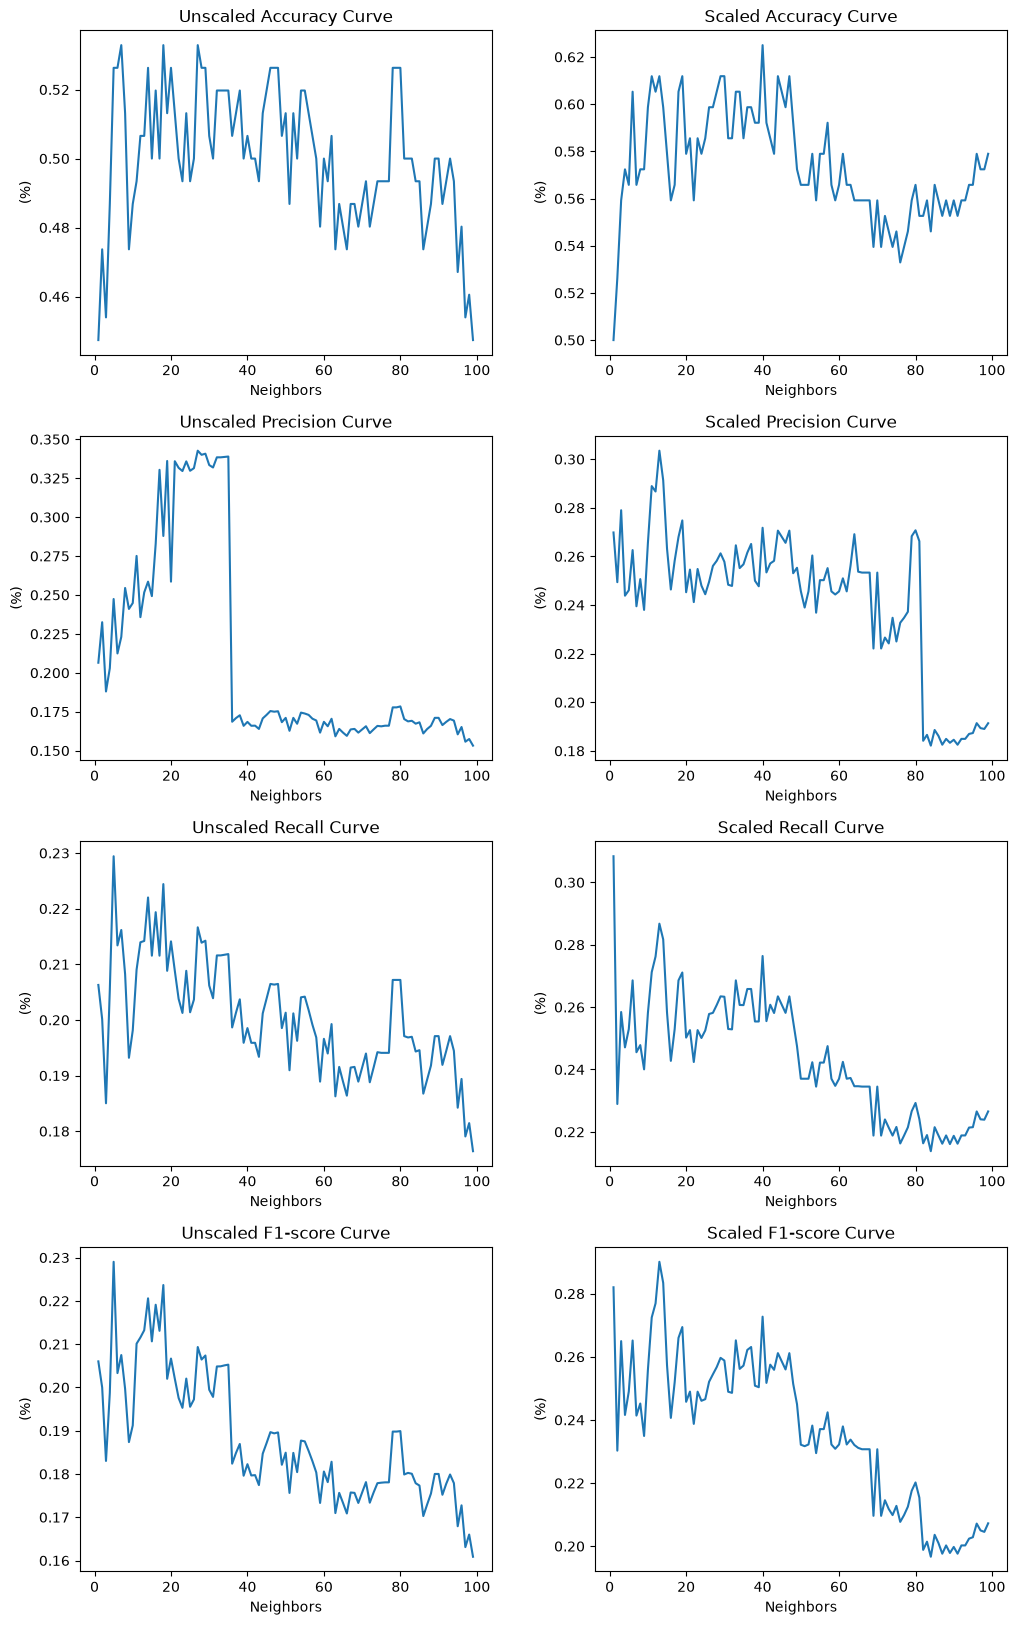

Score difference between scaled and unscaled data for each metric:
(Negative means unscaled data has better score, meanwhile positive means scaled data has better score)

- Accuracy: 0.07376395534290271
- Precision: 0.03208637062155859
- Recall: 0.04286871237628814
- F1-score: 0.048168850068521014

Best neighbor based on accuracy (starts from 1):
- Unscaled: 7 (0.5328947368421053)
- Scaled: 40 (0.625)


In [47]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# JANGAN DIUBAH!
NROWS = 4
NCOLS = 2
NEIGHBORS = range(1, 100)

precision_raw = []
precision_scaled = []

recall_raw = []
recall_scaled = []

f1_raw = []
f1_scaled = []

acc_raw = []
acc_scaled = []

for i in NEIGHBORS:
    score_dict = metric_collection[i-1]
    
    precision_raw.append(score_dict["raw"]["report"]["macro avg"]["precision"])
    precision_scaled.append(score_dict["scaled"]["report"]["macro avg"]["precision"])
    
    recall_raw.append(score_dict["raw"]["report"]["macro avg"]["recall"])
    recall_scaled.append(score_dict["scaled"]["report"]["macro avg"]["recall"])
    
    f1_raw.append(score_dict["raw"]["report"]["macro avg"]["f1-score"])
    f1_scaled.append(score_dict["scaled"]["report"]["macro avg"]["f1-score"])
    
    acc_raw.append(score_dict["raw"]["accuracy"])
    acc_scaled.append(score_dict["scaled"]["accuracy"])

fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(10, 16))
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.25)

data_collection = [
    [acc_raw, acc_scaled],
    [precision_raw, precision_scaled],
    [recall_raw, recall_scaled],
    [f1_raw, f1_scaled]
]
title_collection = [
    "Accuracy", "Precision", "Recall", "F1-score"
]
detail_collection = [
    "Unscaled", "Scaled"
]

for i in range(NROWS):
    viz_data = data_collection[i]
    curr_title = title_collection[i]
    
    for j in range(NCOLS):
        curr_data = viz_data[j]
        curr_detail = detail_collection[j]
        
        ax[i, j].plot(NEIGHBORS, curr_data)
        ax[i, j].set_title(f"{curr_detail} {curr_title} Curve")
        ax[i, j].set_xlabel("Neighbors")
        ax[i, j].set_ylabel("(%)")
        
plt.show()

print(f"Score difference between scaled and unscaled data for each metric:")
print("(Negative means unscaled data has better score, meanwhile positive means scaled data has better score)\n")
for i in range(len(data_collection)):
    used_for_diff = data_collection[i]
    diff_list = [scaled - raw for raw, scaled in zip(used_for_diff[0], used_for_diff[1])]
    diff_num = sum(diff_list)/len(diff_list)
    print(f"- {title_collection[i]}: {diff_num}")
    
best_acc_raw = np.argmax(acc_raw)
best_acc_scaled = np.argmax(acc_scaled)
print("\nBest neighbor based on accuracy (starts from 1):")
for best_acc, detail, acc_list in zip(
    [best_acc_raw, best_acc_scaled],
    detail_collection,
    [acc_raw, acc_scaled]
):
    print(f"- {detail}: {best_acc+1} ({acc_list[best_acc]})")

# 5. Analisis

Eksperimen ini menunjukkan bahwa model mengalami kenaikan performa apabila scaling data diterapkan untuk membuat representasi fitur lebih bermakna dan jumlah neighbor diatur sedemikian rupa untuk memengaruhi performa klasifikasi.

# 6. Kesimpulan dan Saran

Agar lebih satisfying, coba memakai dataset yang memiliki class balance lebih bagus :)